# Literature-Based Humanization on UNSEEN M4 Benchmark — Falcon Detector
# Tests domain-agnostic P_LIT3 prompt (designed from published research, NO data peeking)
# on M4 benchmark data (never used in prompt design)
# This is the CLEAN experiment: no data leakage.

In [1]:
# Install compatible stack: PyTorch 2.5.1 (P100+T4) + matching torchvision + transformers
import subprocess, sys

# Install torch + torchvision together (matching versions)
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 
    'torch==2.5.1+cu121', 'torchvision==0.20.1+cu121', 
    '--index-url', 'https://download.pytorch.org/whl/cu121', '-q'])

# Install compatible transformers
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 
    'transformers==4.46.3', 'accelerate==1.1.1', 'bitsandbytes', 'scipy', 'scikit-learn', '-q'])

import torch
print(f'PyTorch {torch.__version__}, CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f'GPU: {props.name}, compute {props.major}.{props.minor}, {props.total_memory/1e9:.1f}GB')
    x = torch.randn(2,2).cuda()
    print(f'CUDA test: {(x @ x).sum().item():.2f}')
    del x

import transformers
print(f'Transformers {transformers.__version__}')

# Verify Falcon import
from transformers import AutoModelForCausalLM
print('Falcon model import OK')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 80.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 47.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 99.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 10.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 35.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 15.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 9.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.5.1+cu121 which is incompatible.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 95.9 MB/s eta 0:00:00
PyTorch 2.5.1+cu121, CUDA: True
GPU: Tesla P100-PCIE-16GB, compute 6.0, 17.1GB
CUDA test: 0.51
Transformers 4.46.3
Falcon model import OK


In [2]:
import gc, os, sys, json, shutil, warnings, zipfile
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import matplotlib.cm as cm
warnings.filterwarnings('ignore')

gc.collect()
torch.cuda.empty_cache()

# Auto-find M4 literature dataset
BASE = '/kaggle/input'
dataset_file = None
dna_src = None
for root, dirs, files in os.walk(BASE):
    for f in files:
        if f == 'm4_literature_dataset.json':
            dataset_file = os.path.join(root, f)
        if f == '__init__.py' and 'dna_detectllm' in root:
            dna_src = os.path.dirname(os.path.join(root, f))
    for d in dirs:
        if d == 'dna_detectllm':
            candidate = os.path.join(root, d)
            if os.path.isfile(os.path.join(candidate, '__init__.py')):
                dna_src = candidate

print(f'Dataset: {dataset_file}')
print(f'DNA module: {dna_src}')

if not os.path.exists('dna_detectllm') and dna_src:
    shutil.copytree(dna_src, 'dna_detectllm', dirs_exist_ok=True)
    print('Copied dna_detectllm')

assert os.path.exists('dna_detectllm/__init__.py'), 'dna_detectllm not found!'
assert dataset_file, 'm4_literature_dataset.json not found!'

sys.path.insert(0, os.getcwd())
from dna_detectllm.metrics import sum_perplexity, entropy

os.environ['HF_TOKEN'] = 'YOUR_HF_TOKEN'
print(f'GPUs: {torch.cuda.device_count()}')

Dataset: /kaggle/input/datasets/mandaliyatanmay/m4-literature-dataset/m4_literature_dataset.json
DNA module: /kaggle/input/datasets/mandaliyatanmay/dna-detectllm-orig/dna_detectllm
Copied dna_detectllm
GPUs: 1


In [3]:
# Load dataset
with open(dataset_file) as f:
    dataset = json.load(f)

human_texts = dataset['human_texts']
ai_texts = dataset['original_ai_texts']
N = len(ai_texts)
model_keys = list(dataset['humanized'].keys())
model_labels = dataset['metadata'].get('models', {})

print(f'Base texts: {N}')
print(f'Human texts: {len(human_texts)}')
print(f'Humanizer models:')
for k in model_keys:
    valid = sum(1 for x in dataset['humanized'][k] if x is not None)
    label = model_labels.get(k, k)
    print(f'  {label}: {valid}/{len(dataset["humanized"][k])}')

Base texts: 100
Human texts: 100
Humanizer models:
  kimi_lit3: 100/100


In [4]:
# Load both models — adapt to GPU type
from transformers import AutoModelForCausalLM, AutoTokenizer
import gc, os, ctypes

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
gc.collect(); torch.cuda.empty_cache()

tokenizer = AutoTokenizer.from_pretrained('tiiuae/falcon-7b')
tokenizer.pad_token = tokenizer.eos_token
MAX_LEN = 512
DEVICE = 'cuda:0'

props = torch.cuda.get_device_properties(0)
compute_cap = (props.major, props.minor)
print(f'GPU: {props.name}, compute {compute_cap[0]}.{compute_cap[1]}')

# T4 (7.5): use 4-bit. P100 (6.0): use fp16 with auto offloading.
if compute_cap >= (7, 0):
    from transformers import BitsAndBytesConfig
    quant_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_quant_type='nf4')
    load_kwargs = dict(quantization_config=quant_config, device_map='auto', low_cpu_mem_usage=True)
    mode = '4-bit'
else:
    load_kwargs = dict(torch_dtype=torch.float16, device_map='auto', low_cpu_mem_usage=True)
    mode = 'fp16+auto'

print(f'Loading with {mode}...')
print('Loading observer...')
observer = AutoModelForCausalLM.from_pretrained('tiiuae/falcon-7b', **load_kwargs)
observer.eval()
print(f'Observer loaded. GPU: {torch.cuda.memory_allocated()/1e9:.1f}GB')

gc.collect(); torch.cuda.empty_cache()
try: ctypes.CDLL('libc.so.6').malloc_trim(0)
except: pass

print('Loading performer...')
performer = AutoModelForCausalLM.from_pretrained('tiiuae/falcon-7b-instruct', **load_kwargs)
performer.eval()
print(f'Performer loaded. GPU: {torch.cuda.memory_allocated()/1e9:.1f}GB')
print('Both models loaded!')

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

GPU: Tesla P100-PCIE-16GB, compute 6.0
Loading with fp16+auto...
Loading observer...


config.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/9.95G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/4.48G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

Performer loaded. GPU: 15.7GB
Both models loaded!


In [5]:
@torch.inference_mode()
def compute_score(text):
    enc = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_LEN, return_token_type_ids=False)
    enc_gpu = {k: v.to(DEVICE) for k, v in enc.items()}
    obs_logits = observer(**enc_gpu).logits.float()
    perf_logits = performer(**enc_gpu).logits.float()
    class EncWrap:
        def __init__(self, d): self.input_ids = d['input_ids']; self.attention_mask = d['attention_mask']
        def to(self, device):
            self.input_ids = self.input_ids.to(device); self.attention_mask = self.attention_mask.to(device)
            return self
    enc_obj = EncWrap(enc_gpu)
    ppl = sum_perplexity(enc_obj, perf_logits)
    x_ppl = entropy(obs_logits, perf_logits, enc_obj, tokenizer.pad_token_id)
    return float(ppl[0] / (2 * x_ppl[0]))

def score_texts(texts, desc='Scoring'):
    scores = []
    for t in tqdm(texts, desc=desc):
        if t is None:
            scores.append(float('nan'))
        else:
            try:
                scores.append(compute_score(t))
            except Exception as e:
                print(f'Error: {e}')
                scores.append(float('nan'))
    return scores

print(f'Sanity: {compute_score("Hello world test sentence"):.4f}')

Sanity: 1.2191


In [6]:
# Score all groups with checkpointing
all_scores = {}

CKPT = 'scores_checkpoint.json'
if os.path.exists(CKPT):
    with open(CKPT) as f:
        all_scores = json.load(f)
    print(f'Loaded checkpoint: {list(all_scores.keys())}')

if 'human' not in all_scores:
    all_scores['human'] = score_texts(human_texts, 'Human')
    with open(CKPT, 'w') as f: json.dump(all_scores, f)

if 'original_ai' not in all_scores:
    all_scores['original_ai'] = score_texts(ai_texts, 'Original AI')
    with open(CKPT, 'w') as f: json.dump(all_scores, f)

for mk in model_keys:
    if mk not in all_scores:
        label = model_labels.get(mk, mk)
        all_scores[mk] = score_texts(dataset['humanized'][mk], f'P5E via {label}')
        with open(CKPT, 'w') as f: json.dump(all_scores, f)
    else:
        print(f'{mk}: already scored')

print('\nAll scoring complete!')

Human:   3%|▎         | 3/100 [00:13<07:46,  4.81s/it]

Error: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 15.89 GiB of which 123.12 MiB is free. Process 6939 has 15.77 GiB memory in use. Of the allocated memory 15.41 GiB is allocated by PyTorch, and 65.98 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Human:   6%|▌         | 6/100 [00:28<07:41,  4.91s/it]

Error: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 15.89 GiB of which 123.12 MiB is free. Process 6939 has 15.77 GiB memory in use. Of the allocated memory 15.41 GiB is allocated by PyTorch, and 65.98 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


Human:   8%|▊         | 8/100 [00:37<07:35,  4.96s/it]

...

Error: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 15.89 GiB of which 123.12 MiB is free. Process 6939 has 15.77 GiB memory in use. Of the allocated memory 15.41 GiB is allocated by PyTorch, and 65.98 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


P5E via kimi_lit3:  87%|████████▋ | 87/100 [06:43<01:06,  5.12s/it]

Error: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 15.89 GiB of which 123.12 MiB is free. Process 6939 has 15.77 GiB memory in use. Of the allocated memory 15.41 GiB is allocated by PyTorch, and 65.98 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)


P5E via kimi_lit3: 100%|██████████| 100/100 [07:41<00:00,  4.62s/it]


All scoring complete!


In [7]:
# === ANALYSIS ===
def valid(s): return [x for x in s if x is not None and not (isinstance(x, float) and x != x)]

hv = valid(all_scores['human'])
av = valid(all_scores['original_ai'])
hm, am = np.mean(hv), np.mean(av)
gap = hm - am
GMM = (hm + am) / 2  # dynamic threshold

print(f'M4 Benchmark — Falcon Detector')
print(f'Human mean: {hm:.4f}  |  AI mean: {am:.4f}  |  Gap: {gap:.4f}')
print(f'Dynamic threshold: {GMM:.4f}')
print()

results = {}
print(f'{"Humanizer":<35} {"Mean":>7} {"AUROC":>7} {"Gap%":>7} {"Evade%":>7}')
print('='*70)

auroc_ai = roc_auc_score([1]*len(hv)+[0]*len(av), hv+av)
det_ai = sum(1 for s in av if s < GMM)/len(av)*100
print(f'{"Original AI":<35} {am:>7.4f} {auroc_ai:>7.4f} {0:>6.1f}% {100-det_ai:>6.1f}%')

for mk in model_keys:
    sv = valid(all_scores[mk])
    if len(sv) == 0: continue
    label = model_labels.get(mk, mk)
    m = np.mean(sv)
    auroc = roc_auc_score([1]*len(hv)+[0]*len(sv), hv+sv)
    gap_closed = (m - am) / gap * 100 if gap != 0 else 0
    evade = sum(1 for s in sv if s >= GMM)/len(sv)*100
    results[mk] = {'label': label, 'mean': m, 'auroc': auroc, 'gap_closed': gap_closed,
                    'evade_rate': evade, 'n': len(sv), 'scores': sv}
    print(f'{label:<35} {m:>7.4f} {auroc:>7.4f} {gap_closed:>6.1f}% {evade:>6.1f}%')

ranked = sorted(results.items(), key=lambda x: x[1]['auroc'])
print(f'\n=== LIT3 on M4 (unseen): Does literature-based prompt fool Falcon? ===')
for i, (mk, r) in enumerate(ranked, 1):
    print(f'{i}. {r["label"]}: AUROC={r["auroc"]:.4f}, Gap={r["gap_closed"]:.1f}%, Evade={r["evade_rate"]:.1f}%')

M4 Benchmark — Falcon Detector
Human mean: 0.6700  |  AI mean: 0.5485  |  Gap: 0.1215
Dynamic threshold: 0.6093

Humanizer                              Mean   AUROC    Gap%  Evade%
Original AI                          0.5485  0.9217    0.0%   19.7%
kimi_lit3                            0.7153  0.1439  137.3%  100.0%

=== LIT3 on M4 (unseen): Does literature-based prompt fool Falcon? ===
1. kimi_lit3: AUROC=0.1439, Gap=137.3%, Evade=100.0%


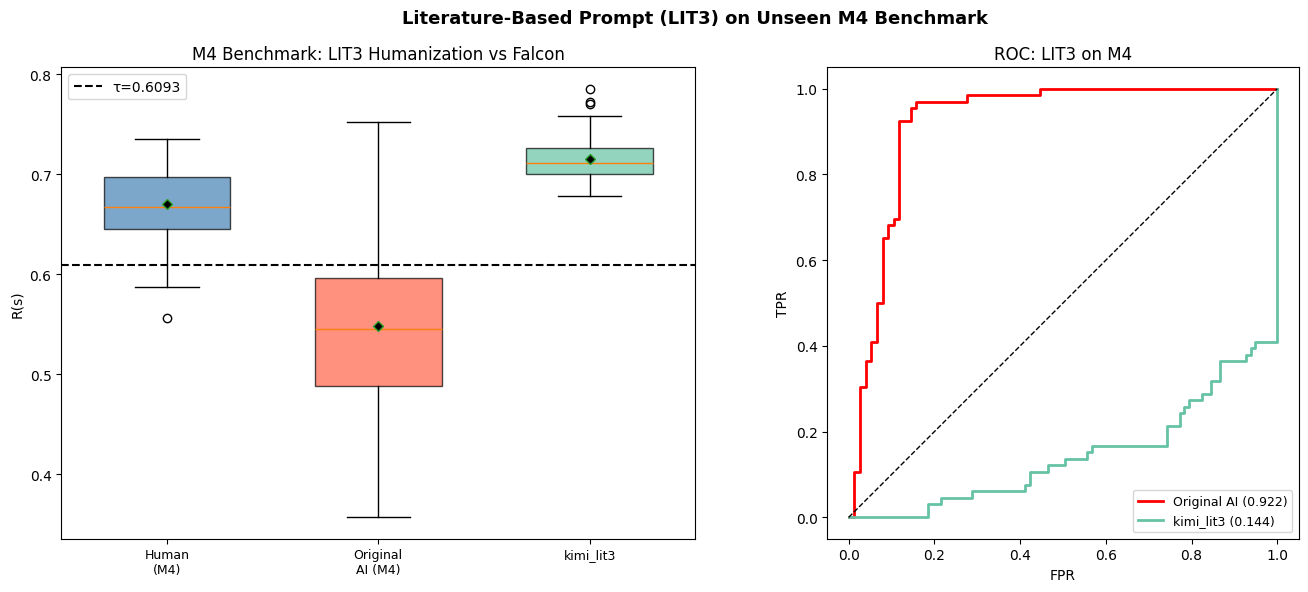

In [8]:
# === PLOTS ===
n_models = len(ranked)
colors = plt.cm.Set2(np.linspace(0, 1, max(n_models, 1)))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplots
bp = axes[0].boxplot([hv, av] + [r['scores'] for _, r in ranked], patch_artist=True, widths=0.6, showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='black', markersize=5))
for patch, c in zip(bp['boxes'], ['steelblue', 'tomato'] + list(colors)):
    patch.set_facecolor(c); patch.set_alpha(0.7)
axes[0].set_xticklabels(['Human\n(M4)', 'Original\nAI (M4)'] + [r['label'] for _, r in ranked], fontsize=9)
axes[0].axhline(GMM, color='black', ls='--', lw=1.5, label=f'τ={GMM:.4f}')
axes[0].set_ylabel('R(s)'); axes[0].set_title('M4 Benchmark: LIT3 Humanization vs Falcon'); axes[0].legend()

# ROC curves
fpr_ai, tpr_ai, _ = roc_curve([1]*len(hv)+[0]*len(av), hv+av)
axes[1].plot(fpr_ai, tpr_ai, 'r-', lw=2, label=f'Original AI ({auroc_ai:.3f})')
for (mk, r), c in zip(ranked, colors):
    fpr, tpr, _ = roc_curve([1]*len(hv)+[0]*len(r['scores']), hv+r['scores'])
    axes[1].plot(fpr, tpr, color=c, lw=2, label=f'{r["label"]} ({r["auroc"]:.3f})')
axes[1].plot([0,1],[0,1],'k--',lw=1)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_title('ROC: LIT3 on M4')
axes[1].legend(fontsize=9); axes[1].set_aspect('equal')

plt.suptitle('Literature-Based Prompt (LIT3) on Unseen M4 Benchmark', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('m4_lit3_results.png', dpi=150, bbox_inches='tight'); plt.show()

In [9]:
# === SAVE RESULTS ===
output = {
    'experiment': 'Literature-Based LIT3 Humanization on Unseen M4 Benchmark',
    'prompt': 'P_LIT3_combined (literature-based, domain-agnostic)',
    'source_benchmark': 'M4 (multi-domain, multi-generator, UNSEEN)',
    'detector': 'Falcon-7B + Falcon-7B-Instruct (DNA-DetectLLM)',
    'humanizer_model': 'Kimi-K2 (moonshotai/kimi-k2-instruct)',
    'note': 'NO data was used to design this prompt. Based on published AI writing research only.',
    'n_texts': N,
    'threshold': float(GMM),
    'human': {'mean': float(hm), 'std': float(np.std(hv)), 'n': len(hv)},
    'original_ai': {'mean': float(am), 'std': float(np.std(av)), 'n': len(av), 'auroc': float(auroc_ai)},
    'humanizer_models': {}
}
for mk, r in results.items():
    output['humanizer_models'][mk] = {
        'label': r['label'], 'mean': float(r['mean']),
        'std': float(np.std(r['scores'])), 'n': r['n'],
        'auroc': float(r['auroc']), 'gap_closed': float(r['gap_closed']),
        'evade_rate': float(r['evade_rate']),
    }
output['all_scores'] = {k: [float(s) if s == s else None for s in v] for k, v in all_scores.items()}

with open('m4_lit3_results.json', 'w') as f:
    json.dump(output, f, indent=2)
print('Saved m4_lit3_results.json')

print(f'\n{"="*60}')
print('M4 BENCHMARK — LITERATURE-BASED PROMPT SUMMARY')
print(f'{"="*60}')
if ranked:
    best_mk, best_r = ranked[0]
    print(f'LIT3 + Kimi on M4: AUROC={best_r["auroc"]:.4f}')
    print(f'  Gap closed: {best_r["gap_closed"]:.1f}%')
    print(f'  Evasion rate: {best_r["evade_rate"]:.1f}%')
    print(f'  Original AI AUROC: {auroc_ai:.4f}')
    if best_r["auroc"] < 0.6:
        print('  → LITERATURE-BASED PROMPT FOOLS FALCON ON UNSEEN DATA!')
    elif best_r["auroc"] < 0.8:
        print('  → Partial evasion — prompt needs refinement')
    else:
        print('  → Prompt does not fool Falcon on this benchmark')

Saved m4_lit3_results.json

M4 BENCHMARK — LITERATURE-BASED PROMPT SUMMARY
LIT3 + Kimi on M4: AUROC=0.1439
  Gap closed: 137.3%
  Evasion rate: 100.0%
  Original AI AUROC: 0.9217
  → LITERATURE-BASED PROMPT FOOLS FALCON ON UNSEEN DATA!
